In [ ]:
import pandas as pd 

import os

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame display

In [3]:
MEAN_SENSOR_FW_NO_LAG_PATH = '../Data/CleanData/Trial_2_Mean_Sensor_FW_No_Lag.csv'
MEAN_SENSOR_FW_LAG_1_PATH = '../Data/CleanData/Trial_2_Mean_Sensor_FW_Lag_1.csv'
MEAN_SENSOR_FW_LAG_2_PATH = '../Data/CleanData/Trial_2_Mean_Sensor_FW_Lag_2.csv'

def load_no_lag_data():
    return pd.read_csv(MEAN_SENSOR_FW_NO_LAG_PATH)

def load_lag_1_data():
    return pd.read_csv(MEAN_SENSOR_FW_LAG_1_PATH)

def load_lag_2_data():
    return pd.read_csv(MEAN_SENSOR_FW_LAG_2_PATH)


In [5]:
print(load_lag_2_data())

     day  plant_id  total_fresh_weight_g  carbon_dioxide  \
0    8.0       1.0                  49.0       -0.510252   
1    8.0       2.0                  46.0       -0.510252   
2    8.0       3.0                  51.0       -0.510252   
3    8.0       4.0                  42.0       -0.510252   
4    8.0       5.0                  50.0       -0.510252   
5    8.0       6.0                  46.0       -0.510252   
6    8.0       6.0                  46.0       -0.510252   
7    8.0       7.0                  44.0       -0.510252   
8    8.0       8.0                  50.0       -0.510252   
9    8.0       9.0                  46.0       -0.510252   
10  12.0       1.0                  48.0        1.234844   
11  12.0       2.0                  51.0        1.234844   
12  12.0       3.0                  54.0        1.234844   
13  12.0       4.0                  55.0        1.234844   
14  12.0       5.0                  45.0        1.234844   
15  12.0       6.0                  50.0

In [7]:
import statsmodels.formula.api as smf


# drop non-predictors
model_df = load_lag_2_data().drop(columns=['plant_id', 'day'])

model_1 = smf.ols(
    formula="""
        total_fresh_weight_g
        ~ carbon_dioxide
        + temp_env
        + humidity
        + pressure
        + electrical_conductivity
        + temp_nutr
        + weight_lag_1
        + weight_lag_2
    """,
    data=model_df
).fit()

print(model_1.summary())

                             OLS Regression Results                             
Dep. Variable:     total_fresh_weight_g   R-squared:                       0.990
Model:                              OLS   Adj. R-squared:                  0.988
Method:                   Least Squares   F-statistic:                     709.4
Date:                  Fri, 20 Mar 2026   Prob (F-statistic):           3.01e-49
Time:                          12:34:55   Log-Likelihood:                -190.15
No. Observations:                    60   AIC:                             396.3
Df Residuals:                        52   BIC:                             413.1
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [8]:
# dictionary for colors of coefficients
coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    # 'volume': 'brown',
    'temp_nutr': 'pink',
    # 'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

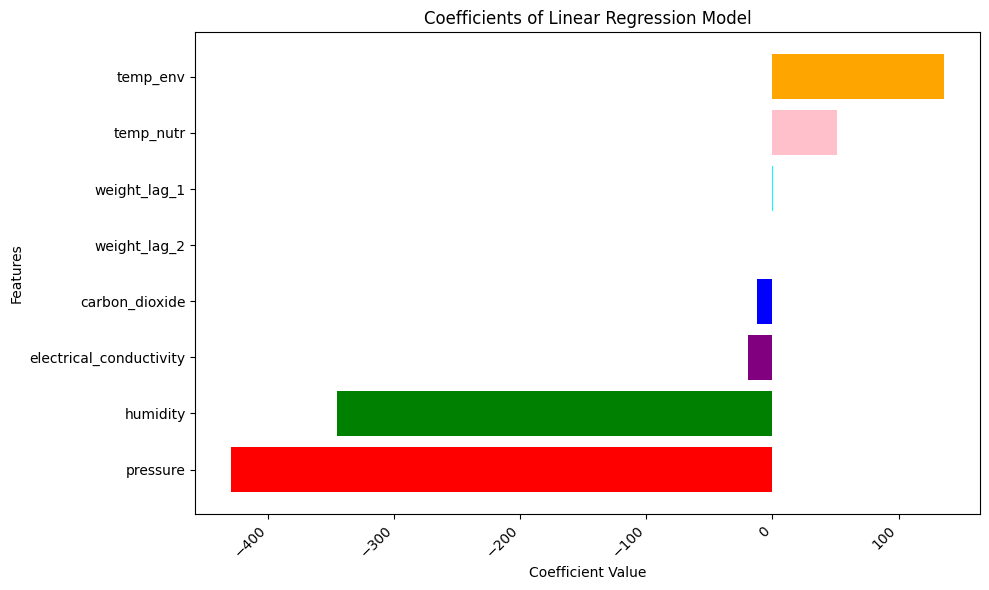

In [9]:
# bargraph of coefficients
# use the colors from the dictionary


from matplotlib import colors
import matplotlib.pyplot as plt
coefficients = model_1.params[1:]  # Exclude the intercept
coefficients = coefficients.sort_values(ascending=True)  # Sort coefficients for better visualization
features = coefficients.index
colors = [coef_colors[feature] for feature in features]

    
plt.figure(figsize=(10, 6))
plt.barh(features, coefficients, color=colors)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title('Coefficients of Linear Regression Model')
plt.tight_layout()

# save figure
plt.savefig('../Figures/regression_coefficients.png')
plt.show()

* Humidity and water temperature have strongest positively associated features with lettuce weight. 
* However, examining the confidence interval tells us that the coefficient of water temperature could be zero. We are 95% confident that humidity is a positive predictor of lettuce weight. 
* Adiditonally there is strong multicollinearity
* r sqaured and rmse is good 
* remove insignificant p values from report 
* add time series neural network model and compare results to OLS

In [24]:
coefficients.index

Index(['volume_flow_rate', 'pressure', 'volume', 'weight_lag_2',
       'electrical_conductivity', 'temp_env', 'weight_lag_1', 'carbon_dioxide',
       'temp_nutr', 'humidity'],
      dtype='object')

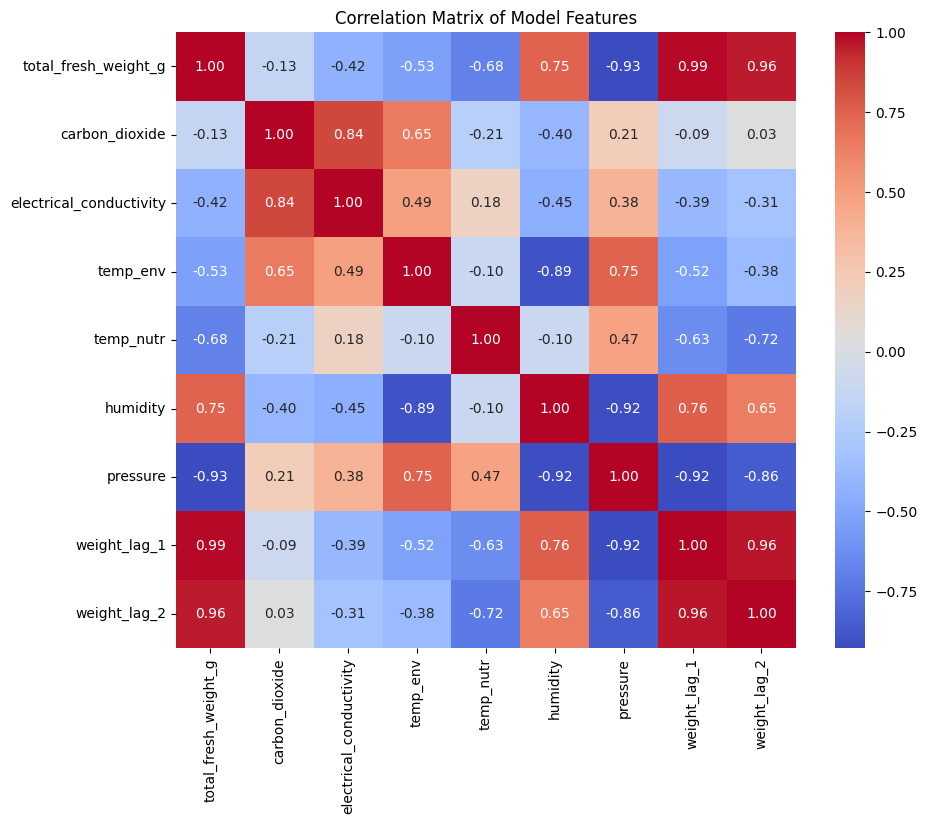

In [10]:
# correlation matrix of model_df
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(model_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Model Features")
# save figure
plt.savefig('../Figures/correlation_matrix.png')
plt.show()